# Faunari · nb-06 — Fine-tune BioCLIP to close the hard-case venomous-recall gap

**What this does.** Frozen BioCLIP features give test venomous-recall **0.99** but only **0.935** on the
hard-case (look-alike) set — and ensembling didn't help, because a few deadly species sit at calibrated
**P(venom) ~= 0** (confidently wrong). Frozen features can't fix that; the **backbone itself** must learn
snake-discriminative features. So we **partially fine-tune** BioCLIP's image encoder (last few transformer
blocks + a new head, discriminative LRs, cost-sensitive loss), then **reuse our exact serving recipe** on the
fine-tuned embeddings (StandardScaler -> cost-sensitive LogReg -> isotonic calibration -> recall>=0.98 threshold)
and refit the Mahalanobis OOD detector. Outputs match `models/bioclip_danger_v1.joblib` schema so the app loads
the v2 with minimal change.

**Run target = Kaggle Notebook with GPU (T4), free tier.** Enable GPU, attach the Faunari dataset, Run All,
then download the 3 artifacts from `/kaggle/working/`.

**Safety discipline.** Select / early-stop on **val**; report on **test** and **hard-case**; **never** tune on
hard-case. Cost-sensitive everywhere: a venomous->non (dangerous->safe) error is ~6x a non->venomous error.

**SMOKE mode.** `SMOKE=True` runs 1 epoch on a tiny subset against LOCAL data on CPU — for validating the code
path on the ARM/CPU dev machine. The shipped default is `SMOKE=False` (full GPU run on Kaggle).

## 0 · Kaggle setup — install `open_clip_torch`
Run this first on Kaggle (skips quietly if already present). Locally in SMOKE mode it is also a no-op if
`open_clip` is already installed.

In [1]:
# Kaggle: install open_clip_torch (no-op if present). Quiet to keep the log readable.
import importlib.util, subprocess, sys

if importlib.util.find_spec("open_clip") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "open_clip_torch"], check=True)
    print("installed open_clip_torch")
else:
    print("open_clip already available -> skipping install")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
installed open_clip_torch


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

## 1 · Config & the `SMOKE` switch
One frozen `Config` is the single source of truth. `SMOKE` forces CPU + a tiny subset + 1 epoch so the whole
code path can be validated locally before the real GPU run. **Ship with `SMOKE = False`.**

In [2]:
from __future__ import annotations

import glob
import json
import os
import random
import warnings
from dataclasses import dataclass, asdict, field
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile, UnidentifiedImageError

ImageFile.LOAD_TRUNCATED_IMAGES = True  # scraped JPEGs are often truncated (nb-03/04 pattern).
warnings.filterwarnings("ignore", category=UserWarning)

try:
    from tqdm.auto import tqdm
except ImportError:  # tqdm optional -> no-op wrapper.
    def tqdm(it, **_):  # type: ignore
        return it

# ===================== THE SWITCH ===================== #
SMOKE = False   # True = tiny 1-epoch CPU run on LOCAL data (dev validation). SHIP AS False.
# ====================================================== #

SEED = 42

In [3]:
@dataclass(frozen=True)
class Config:
    """Single source of truth for every knob (logged below). SMOKE shrinks the heavy ones."""
    seed: int = SEED
    backbone_id: str = "hf-hub:imageomics/bioclip"
    embedding_dim: int = 512
    positive_class: str = "venomous"

    # --- data location (portable: Kaggle default, local override for SMOKE) ---
    data_root: str = "/kaggle/input"
    image_size: int = 224

    # --- partial fine-tune ---
    n_unfrozen_blocks: int = 3          # unfreeze the last N transformer blocks of the image encoder.
    head_hidden: int = 0                # 0 = plain linear head (512->2); >0 inserts one hidden layer.
    dropout: float = 0.1

    # --- optimisation (discriminative LRs: small backbone, larger head) ---
    epochs: int = 20
    batch_size: int = 32
    lr_head: float = 1e-3
    lr_backbone: float = 1e-5
    weight_decay: float = 1e-4
    warmup_frac: float = 0.1            # cosine schedule with a short linear warmup.
    label_smoothing: float = 0.0
    grad_clip: float = 1.0

    # --- cost-sensitive loss: venomous->non (dangerous->safe) penalised ~6x (mirrors nb-05) ---
    venomous_class_weight: float = 6.0
    nonvenomous_class_weight: float = 1.0

    # --- early stopping on VAL venomous recall (the safety metric, NEVER hard-case) ---
    early_stop_patience: int = 5
    es_threshold: float = 0.5           # recall is measured at this fixed prob during training (head softmax).

    # --- serving head recipe (reuse v1 exactly on fine-tuned embeddings) ---
    logreg_C: float = 1.0
    logreg_max_iter: int = 5000
    target_recall: float = 0.98         # release gate; threshold = highest val thr with recall>=this.
    ece_bins: int = 10
    ood_percentile: float = 99.0        # matches src/config OOD_PERCENTILE.
    gate: float = 0.98

    num_workers: int = 2                # Kaggle GPU: a couple of loader workers help; SMOKE forces 0.


def make_config(smoke: bool) -> Config:
    """Return the full-run Config, or a tiny CPU-friendly one when smoke=True."""
    if not smoke:
        return Config()
    # SMOKE: local data, 1 epoch, tiny everything, 0 workers (CPU/Windows-safe).
    return Config(
        data_root="e:/Coding_Notes/Faunari",
        epochs=1, batch_size=8, n_unfrozen_blocks=1,
        early_stop_patience=1, num_workers=0,
    )


CFG = make_config(SMOKE)
print(f"SMOKE = {SMOKE}")
print(json.dumps(asdict(CFG), indent=2))

SMOKE = False
{
  "seed": 42,
  "backbone_id": "hf-hub:imageomics/bioclip",
  "embedding_dim": 512,
  "positive_class": "venomous",
  "data_root": "/kaggle/input",
  "image_size": 224,
  "n_unfrozen_blocks": 3,
  "head_hidden": 0,
  "dropout": 0.1,
  "epochs": 20,
  "batch_size": 32,
  "lr_head": 0.001,
  "lr_backbone": 1e-05,
  "weight_decay": 0.0001,
  "warmup_frac": 0.1,
  "label_smoothing": 0.0,
  "grad_clip": 1.0,
  "venomous_class_weight": 6.0,
  "nonvenomous_class_weight": 1.0,
  "early_stop_patience": 5,
  "es_threshold": 0.5,
  "logreg_C": 1.0,
  "logreg_max_iter": 5000,
  "target_recall": 0.98,
  "ece_bins": 10,
  "ood_percentile": 99.0,
  "gate": 0.98,
  "num_workers": 2
}


## 2 · Reproducibility & device
Seed every RNG; pick CUDA when present (Kaggle T4), else CPU (local SMOKE). AMP is enabled only on CUDA.

In [4]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader


def set_all_seeds(seed: int) -> None:
    """Seed python / numpy / torch so the whole pipeline is reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_all_seeds(CFG.seed)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
print(f"torch {torch.__version__} | device: {DEVICE} | AMP: {USE_AMP}")

torch 2.10.0+cu128 | device: cuda | AMP: True


## 3 · Locate the data (portable) & load the index
Glob for `**/kaggle_index.csv` under `DATA_ROOT`; set `RAW = <csv>.parent.parent / "raw"`; full image path =
`RAW / rel_path`. The index already has the conservative Rhabdophis->venomous override applied, so we use its
`venom_label`/`split` **as-is** (no re-split, no re-override).

In [5]:
def locate_index(data_root: str) -> tuple[Path, Path]:
    """Find kaggle_index.csv under data_root and derive the raw image root. Fail loudly if absent."""
    matches = sorted(glob.glob(os.path.join(data_root, "**", "kaggle_index.csv"), recursive=True))
    if not matches:
        raise FileNotFoundError(
            f"kaggle_index.csv not found under {data_root!r}. On Kaggle, attach the Faunari dataset; "
            f"locally (SMOKE) ensure data/processed/kaggle_index.csv exists.")
    csv_path = Path(matches[0])
    raw_dir = csv_path.parent.parent / "raw"   # <root>/data/processed/kaggle_index.csv -> <root>/data/raw
    if not raw_dir.exists():
        raise FileNotFoundError(f"expected raw image dir at {raw_dir} (csv at {csv_path}) but it is missing.")
    return csv_path, raw_dir


def load_index(csv_path: Path, raw_dir: Path) -> pd.DataFrame:
    """Load the index, validate columns, attach absolute image paths + the binary danger target."""
    df = pd.read_csv(csv_path)
    required = {"rel_path", "split", "venom_label", "species"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"kaggle_index.csv missing columns: {missing}")
    df = df.copy()
    df["path"] = df["rel_path"].map(lambda r: str(raw_dir / r))
    df["y"] = (df["venom_label"] == CFG.positive_class).astype(int)  # 1 = venomous (positive).
    return df


CSV_PATH, RAW_DIR = locate_index(CFG.data_root)
INDEX = load_index(CSV_PATH, RAW_DIR)
print(f"index csv : {CSV_PATH}")
print(f"raw images: {RAW_DIR}")
print(f"rows      : {len(INDEX)}  | splits: {INDEX['split'].value_counts().to_dict()}")
print(f"venom     : {INDEX['venom_label'].value_counts().to_dict()}")

index csv : /kaggle/input/datasets/sharmadhruv7477/faunari-snakes-train/data/processed/kaggle_index.csv
raw images: /kaggle/input/datasets/sharmadhruv7477/faunari-snakes-train/data/raw
rows      : 8343  | splits: {'train': 6443, 'test': 833, 'val': 828, 'hardcase': 239}
venom     : {'venomous': 4387, 'non_venomous': 3956}


## 4 · SMOKE subsetting
In SMOKE we keep a tiny, **class-balanced** slice of every split so the code path runs in seconds on CPU while
still exercising both classes and all four splits. Full runs use every row.

In [6]:
def smoke_subset(df: pd.DataFrame, per_class_per_split: int, seed: int) -> pd.DataFrame:
    """Tiny balanced slice: up to `per_class_per_split` rows of each (split, y) group. groupby+sample is
    pandas-3.0 safe (we do NOT use groupby.apply, which would drop the group columns)."""
    rng = np.random.RandomState(seed)
    keep: list[pd.DataFrame] = []
    for (_split, _y), g in df.groupby(["split", "y"], sort=False):
        n = min(per_class_per_split, len(g))
        keep.append(g.sample(n=n, random_state=rng))
    out = pd.concat(keep, axis=0).reset_index(drop=True)
    return out


if SMOKE:
    INDEX = smoke_subset(INDEX, per_class_per_split=12, seed=CFG.seed)
    print("SMOKE subset ->", INDEX.groupby(["split", "venom_label"]).size().to_dict())
else:
    print("full run -> using every row")

print(f"working rows: {len(INDEX)}")

full run -> using every row
working rows: 8343


## 5 · Backbone + transforms
Load BioCLIP via `open_clip.create_model_and_transforms`. We keep the model's **eval preprocess** for
val/test/hard-case and embedding extraction (deterministic), and build a **train-only augmentation** pipeline
(random-resized-crop, h-flip, small rotation, mild colour jitter) sharing BioCLIP's normalisation. If BioCLIP
fails to load we fall back to CLIP ViT-B/16 and flag it loudly (results then are NOT BioCLIP).

In [7]:
import open_clip
from torchvision import transforms as T

BIOCLIP_FELL_BACK = False


def build_backbone() -> tuple[nn.Module, "callable", "callable"]:
    """Return (model, eval_preprocess, train_preprocess). model.encode_image -> [B,512] features."""
    global BIOCLIP_FELL_BACK
    try:
        model, _, eval_preprocess = open_clip.create_model_and_transforms(CFG.backbone_id)
        print(f"BioCLIP loaded from {CFG.backbone_id}.")
    except Exception as e:  # noqa: BLE001 — do not swallow; flag the fallback loudly.
        BIOCLIP_FELL_BACK = True
        print("!" * 70)
        print(f"!! BioCLIP FAILED TO LOAD ({type(e).__name__}: {e}) -> FALLING BACK to CLIP ViT-B/16 (openai).")
        print("!! Results below are NOT BioCLIP.")
        print("!" * 70)
        model, _, eval_preprocess = open_clip.create_model_and_transforms("ViT-B-16", pretrained="openai")

    # Recover the normalisation stats from the eval preprocess to reuse in train augmentation.
    norm = next((t for t in eval_preprocess.transforms if isinstance(t, T.Normalize)), None)
    mean = tuple(norm.mean) if norm is not None else (0.48145466, 0.4578275, 0.40821073)
    std = tuple(norm.std) if norm is not None else (0.26862954, 0.26130258, 0.27577711)

    train_preprocess = T.Compose([
        T.RandomResizedCrop(CFG.image_size, scale=(0.7, 1.0), ratio=(0.8, 1.25)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(degrees=12),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])
    return model.to(DEVICE), eval_preprocess, train_preprocess


MODEL, EVAL_TF, TRAIN_TF = build_backbone()
EMB_DIM = MODEL.encode_image(torch.zeros(1, 3, CFG.image_size, CFG.image_size, device=DEVICE)).shape[1]
print(f"embedding dim: {EMB_DIM}  | fell back: {BIOCLIP_FELL_BACK}")
assert EMB_DIM == CFG.embedding_dim, f"expected {CFG.embedding_dim}-d, got {EMB_DIM}"

open_clip_config.json:   0%|          | 0.00/469 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

BioCLIP loaded from hf-hub:imageomics/bioclip.
embedding dim: 512  | fell back: False


## 6 · Partial fine-tune model
**Why partial fine-tune.** ~4k images, long-tailed and look-alike-hard, on a free T4 -> full fine-tuning would
overfit and be slow. We **freeze most of the image encoder**, unfreeze only the **last N transformer blocks +
the final layernorm**, and add a small **classification head** (512 -> 2). Discriminative LRs (tiny for the
backbone, larger for the head) let the head adapt fast while the backbone nudges gently. This is the standard
data-efficient recipe for adapting a strong pretrained ViT to a small specialised set.

In [8]:
class FineTuneClassifier(nn.Module):
    """BioCLIP image encoder (mostly frozen) -> small head -> 2-logit danger classifier."""

    def __init__(self, backbone: nn.Module, emb_dim: int, n_unfrozen: int,
                 head_hidden: int, dropout: float) -> None:
        super().__init__()
        self.backbone = backbone
        self._freeze_then_unfreeze(n_unfrozen)
        if head_hidden > 0:
            self.head = nn.Sequential(
                nn.Dropout(dropout), nn.Linear(emb_dim, head_hidden), nn.GELU(),
                nn.Dropout(dropout), nn.Linear(head_hidden, 2))
        else:
            self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(emb_dim, 2))

    def _transformer_blocks(self) -> list[nn.Module]:
        """Locate the ViT residual-attention blocks inside open_clip's CLIP image tower."""
        visual = self.backbone.visual
        # open_clip ViT: visual.transformer.resblocks is the ModuleList of blocks.
        if hasattr(visual, "transformer") and hasattr(visual.transformer, "resblocks"):
            return list(visual.transformer.resblocks)
        raise AttributeError("could not locate visual.transformer.resblocks on the backbone.")

    def _freeze_then_unfreeze(self, n_unfrozen: int) -> None:
        """Freeze the whole encoder, then re-enable grads on the last `n_unfrozen` blocks + final LN."""
        for p in self.backbone.parameters():
            p.requires_grad_(False)
        blocks = self._transformer_blocks()
        for blk in blocks[-n_unfrozen:] if n_unfrozen > 0 else []:
            for p in blk.parameters():
                p.requires_grad_(True)
        # Final layernorm of the visual tower (open_clip names it ln_post) -> let it adapt too.
        ln_post = getattr(self.backbone.visual, "ln_post", None)
        if isinstance(ln_post, nn.Module):
            for p in ln_post.parameters():
                p.requires_grad_(True)
        n_total = len(blocks)
        n_tune = sum(p.numel() for p in self.backbone.parameters() if p.requires_grad)
        print(f"backbone blocks: {n_total} | unfrozen last {n_unfrozen} | trainable backbone params: {n_tune:,}")

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Image embedding (gradients flow only through unfrozen parts)."""
        return self.backbone.encode_image(x)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.encode(x))

    def param_groups(self, lr_head: float, lr_backbone: float, weight_decay: float) -> list[dict]:
        """Discriminative LRs: small LR for unfrozen backbone params, larger LR for the head."""
        head_params = [p for p in self.head.parameters() if p.requires_grad]
        bb_params = [p for p in self.backbone.parameters() if p.requires_grad]
        return [
            {"params": head_params, "lr": lr_head, "weight_decay": weight_decay},
            {"params": bb_params, "lr": lr_backbone, "weight_decay": weight_decay},
        ]


CLF = FineTuneClassifier(MODEL, EMB_DIM, CFG.n_unfrozen_blocks, CFG.head_hidden, CFG.dropout).to(DEVICE)
n_trainable = sum(p.numel() for p in CLF.parameters() if p.requires_grad)
print(f"total trainable params (backbone+head): {n_trainable:,}")

backbone blocks: 12 | unfrozen last 3 | trainable backbone params: 21,265,152
total trainable params (backbone+head): 21,266,178


## 7 · Datasets & loaders
One `Dataset` class with a swappable transform: train split gets augmentation, others get the deterministic eval
preprocess. Unreadable images yield a blank tensor (flagged, not silently dropped) so batch shapes stay valid.

In [9]:
class SnakeImageDataset(Dataset):
    """Yields (image_tensor, label) by path; applies the given transform (train=aug, else eval)."""

    def __init__(self, frame: pd.DataFrame, transform, image_size: int) -> None:
        self.paths = frame["path"].tolist()
        self.labels = frame["y"].to_numpy().astype(np.int64)
        self.transform = transform
        self.blank = (image_size, image_size)

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, i: int):
        try:
            with Image.open(self.paths[i]) as im:
                tensor = self.transform(im.convert("RGB"))
        except (UnidentifiedImageError, OSError, ValueError):
            tensor = torch.zeros(3, *self.blank)  # keep row aligned; corruption is rare post-dedup.
        return tensor, int(self.labels[i])


def make_loader(frame: pd.DataFrame, transform, shuffle: bool) -> DataLoader:
    """Build a DataLoader for one split (workers/pin from CFG/device)."""
    ds = SnakeImageDataset(frame, transform, CFG.image_size)
    return DataLoader(ds, batch_size=CFG.batch_size, shuffle=shuffle,
                      num_workers=CFG.num_workers, pin_memory=(DEVICE.type == "cuda"), drop_last=False)


SPLITS = {s: INDEX[INDEX["split"] == s].reset_index(drop=True) for s in ["train", "val", "test", "hardcase"]}
train_loader = make_loader(SPLITS["train"], TRAIN_TF, shuffle=True)
val_loader = make_loader(SPLITS["val"], EVAL_TF, shuffle=False)
for s, f in SPLITS.items():
    print(f"{s:9s}: n={len(f):5d}  venomous={int(f['y'].sum()):4d}  non={int((f['y']==0).sum()):4d}")

train    : n= 6443  venomous=3454  non=2989
val      : n=  828  venomous= 401  non= 427
test     : n=  833  venomous= 409  non= 424
hardcase : n=  239  venomous= 123  non= 116


## 8 · Training loop — cost-sensitive, AMP, cosine schedule, early-stop on VAL recall
Weighted cross-entropy up-weights the venomous class (~6x) so the optimiser fears dangerous->safe errors.
AdamW + cosine schedule with linear warmup. AMP on GPU. We track **val venomous recall** each epoch and keep
the best checkpoint; early-stop on patience. **Hard-case is never touched here.**

In [10]:
import math
from sklearn.metrics import recall_score


def build_optimizer_scheduler(model: FineTuneClassifier, steps_per_epoch: int):
    """AdamW with discriminative LRs + cosine schedule (linear warmup) over the full run."""
    opt = torch.optim.AdamW(model.param_groups(CFG.lr_head, CFG.lr_backbone, CFG.weight_decay))
    total_steps = max(1, steps_per_epoch * CFG.epochs)
    warmup_steps = max(1, int(CFG.warmup_frac * total_steps))

    def lr_lambda(step: int) -> float:
        if step < warmup_steps:
            return step / warmup_steps
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * prog))

    sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)
    return opt, sched


@torch.no_grad()
def val_venom_recall(model: FineTuneClassifier, loader: DataLoader) -> float:
    """Venomous recall on val using the head softmax at es_threshold (training-time monitor only)."""
    model.eval()
    ys, ps = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        prob = torch.softmax(model(xb), dim=1)[:, 1]
        ps.append(prob.detach().cpu().numpy()); ys.append(yb.numpy())
    y = np.concatenate(ys); p = np.concatenate(ps)
    pred = (p >= CFG.es_threshold).astype(int)
    return float(recall_score(y, pred, pos_label=1, zero_division=0))


def train(model: FineTuneClassifier) -> dict:
    """Fine-tune; keep the best state_dict by VAL venomous recall (tie-break: lower val loss)."""
    class_w = torch.tensor([CFG.nonvenomous_class_weight, CFG.venomous_class_weight],
                           dtype=torch.float32, device=DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_w, label_smoothing=CFG.label_smoothing)
    opt, sched = build_optimizer_scheduler(model, len(train_loader))
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    best = {"recall": -1.0, "epoch": -1, "state": None}
    history: list[dict] = []
    no_improve = 0

    for epoch in range(CFG.epochs):
        model.train()
        running = 0.0
        for xb, yb in tqdm(train_loader, desc=f"epoch {epoch+1}/{CFG.epochs}"):
            xb = xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                loss = criterion(model(xb), yb)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
            scaler.step(opt); scaler.update(); sched.step()
            running += float(loss.detach()) * xb.size(0)
        train_loss = running / max(1, len(train_loader.dataset))
        vrec = val_venom_recall(model, val_loader)
        history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_venom_recall": vrec})
        print(f"  epoch {epoch+1}: train_loss={train_loss:.4f}  val_venom_recall={vrec:.3f}")

        if vrec > best["recall"]:
            best = {"recall": vrec, "epoch": epoch + 1,
                    "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= CFG.early_stop_patience:
                print(f"  early stop at epoch {epoch+1} (no val improvement for {no_improve}).")
                break

    if best["state"] is not None:
        model.load_state_dict(best["state"])
    print(f"best epoch={best['epoch']}  best val_venom_recall={best['recall']:.3f}")
    return {"history": history, "best_epoch": best["epoch"], "best_val_recall": best["recall"]}


TRAIN_RESULT = train(CLF)

epoch 1/20:   0%|          | 0/202 [00:00<?, ?it/s]

  epoch 1: train_loss=0.3883  val_venom_recall=0.985


epoch 2/20:   0%|          | 0/202 [00:00<?, ?it/s]

  epoch 2: train_loss=0.2270  val_venom_recall=0.970


epoch 3/20:   0%|          | 0/202 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eaae5dc0360>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eaae5dc0360>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  epoch 5: train_loss=0.0681  val_venom_recall=0.950


epoch 6/20:   0%|          | 0/202 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eaae5dc0360>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7eaae5dc0360>

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
assert self._parent_pid == os.getpid(), 'can only test a child process'    
self._shutdown_workers()  
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
       if w.is_alive(): 
       ^ ^ ^ ^ ^^^^^^^^^^^^^^^^^^^^^

  epoch 6: train_loss=0.0514  val_venom_recall=0.913
  early stop at epoch 6 (no val improvement for 5).
best epoch=1  best val_venom_recall=0.985


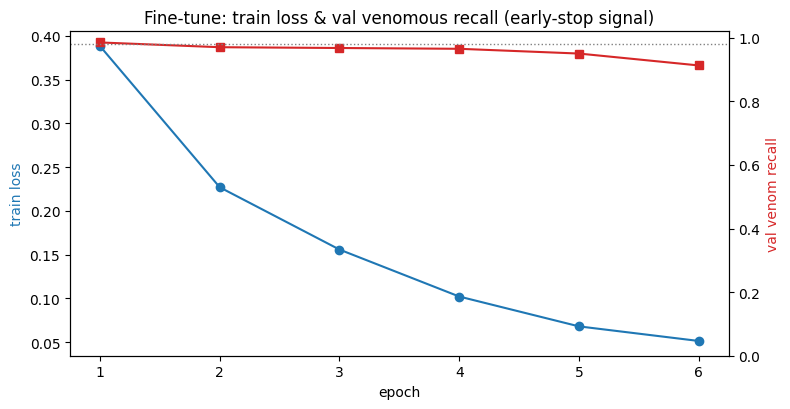

 epoch  train_loss  val_venom_recall
     1    0.388321          0.985037
     2    0.227026          0.970075
     3    0.155862          0.967581
     4    0.102205          0.965087
     5    0.068117          0.950125
     6    0.051446          0.912718


In [11]:
# Training curve: val venomous recall (the early-stop signal) + train loss.
hist = pd.DataFrame(TRAIN_RESULT["history"])
if len(hist) >= 1:
    fig, ax1 = plt.subplots(figsize=(8, 4.2))
    ax1.plot(hist["epoch"], hist["train_loss"], "o-", color="#1f77b4", label="train loss")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("train loss", color="#1f77b4")
    ax2 = ax1.twinx()
    ax2.plot(hist["epoch"], hist["val_venom_recall"], "s-", color="#d62728", label="val venom recall")
    ax2.axhline(CFG.target_recall, color="grey", ls=":", lw=1)
    ax2.set_ylabel("val venom recall", color="#d62728"); ax2.set_ylim(0, 1.02)
    ax1.set_title("Fine-tune: train loss & val venomous recall (early-stop signal)")
    plt.tight_layout(); plt.show()
print(hist.to_string(index=False))

## 9 · Extract fine-tuned embeddings for ALL splits
Freeze the fine-tuned encoder and extract a 512-d embedding per image (eval preprocess, no grad). These feed our
exact serving head — so the deployed model is the same shape/format as v1, just on better features.

In [12]:
@torch.no_grad()
def extract_embeddings(model: FineTuneClassifier, frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    """Return (X [N,512] float32, y [N] int) for a split using the eval preprocess (deterministic)."""
    model.eval()
    loader = make_loader(frame, EVAL_TF, shuffle=False)
    embs, ys = [], []
    for xb, yb in tqdm(loader, desc="embedding"):
        xb = xb.to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            e = model.encode(xb)
        embs.append(e.float().detach().cpu().numpy()); ys.append(yb.numpy())
    return np.concatenate(embs).astype(np.float32), np.concatenate(ys).astype(int)


EMB = {s: extract_embeddings(CLF, SPLITS[s]) for s in ["train", "val", "test", "hardcase"]}
for s, (X, y) in EMB.items():
    print(f"{s:9s}: X={X.shape}  venomous={int(y.sum())}")

embedding:   0%|          | 0/202 [00:00<?, ?it/s]

embedding:   0%|          | 0/26 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eaae5dc0360>
Traceback (most recent call last):
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eaae5dc0360>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

    Traceback (most recent call last):
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
if w.is_alive():    
if w.is_alive(): 
          ^ ^  ^^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
assert self._par

embedding:   0%|          | 0/27 [00:00<?, ?it/s]

embedding:   0%|          | 0/8 [00:00<?, ?it/s]

train    : X=(6443, 512)  venomous=3454
val      : X=(828, 512)  venomous=401
test     : X=(833, 512)  venomous=409
hardcase : X=(239, 512)  venomous=123


## 10 · Serving head — reuse the v1 recipe EXACTLY on fine-tuned embeddings
`StandardScaler -> cost-sensitive LogReg (venom weight 6) -> isotonic calibration on val -> threshold = highest
val threshold with venomous recall >= 0.98`. This is byte-for-byte the recipe in `src/training/export.py`, so
`bioclip_danger_v2.joblib` drops into the app like v1. Feature variant = **raw** (no L2-norm), matching v1.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator


def build_head() -> Pipeline:
    """StandardScaler -> cost-sensitive LogisticRegression (raw features, no L2 — matches v1)."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=CFG.logreg_C, max_iter=CFG.logreg_max_iter,
                                   class_weight={0: CFG.nonvenomous_class_weight,
                                                 1: CFG.venomous_class_weight},
                                   random_state=CFG.seed)),
    ])


def tune_threshold_highest_recall(y_val: np.ndarray, p_val: np.ndarray, target: float) -> float:
    """Highest threshold whose venomous recall >= target (exactly src/training/export._tune_threshold)."""
    best = 0.0
    for t in np.unique(p_val):
        pred = (p_val >= t).astype(int)
        tp = int(((pred == 1) & (y_val == 1)).sum())
        fn = int(((pred == 0) & (y_val == 1)).sum())
        if (tp + fn) and tp / (tp + fn) >= target:
            best = float(t)
    return best


X_tr, y_tr = EMB["train"]
X_val, y_val = EMB["val"]
X_te, y_te = EMB["test"]
X_hc, y_hc = EMB["hardcase"]

pipe = build_head().fit(X_tr, y_tr)                                  # fit on TRAIN only (no leakage).
CALIBRATED = CalibratedClassifierCV(FrozenEstimator(pipe), method="isotonic").fit(X_val, y_val)  # isotonic on VAL.
THRESHOLD = tune_threshold_highest_recall(y_val, CALIBRATED.predict_proba(X_val)[:, 1], CFG.target_recall)
print(f"calibrated isotonic head fitted | threshold (tuned on VAL, recall>={CFG.target_recall}): {THRESHOLD:.4f}")

calibrated isotonic head fitted | threshold (tuned on VAL, recall>=0.98): 0.0824


## 11 · Evaluation — venomous recall first (test AND hard-case), with the gate check
Lead metric is **venomous recall**. We also report balanced accuracy, venomous precision, PR-AUC, ECE, and the
full confusion matrix. Gate = recall >= 0.98 on **both** test and hard-case.

In [14]:
from sklearn.metrics import (precision_score, balanced_accuracy_score,
                             average_precision_score, confusion_matrix)


def expected_calibration_error(y_true: np.ndarray, p: np.ndarray, n_bins: int) -> float:
    """Equal-width-bin ECE on P(venomous) (matches nb-05). 0 = perfectly calibrated."""
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.clip(np.digitize(p, bins) - 1, 0, n_bins - 1)
    n = len(p); ece = 0.0
    for b in range(n_bins):
        m = idx == b
        if m.any():
            ece += (m.sum() / n) * abs(p[m].mean() - y_true[m].mean())
    return float(ece)


@dataclass
class SplitMetrics:
    """Headline metrics for one split at the chosen threshold (venomous recall first)."""
    split: str
    n: int
    venomous_recall: float
    balanced_accuracy: float
    venomous_precision: float
    pr_auc: float
    ece: float
    tn: int
    fp: int
    fn: int   # dangerous->safe MISSES (the safety-critical errors).
    tp: int


def evaluate(name: str, X: np.ndarray, y: np.ndarray) -> tuple[SplitMetrics, np.ndarray]:
    """Calibrated scores -> threshold -> metrics + confusion matrix for one split."""
    scores = CALIBRATED.predict_proba(X)[:, 1]
    pred = (scores >= THRESHOLD).astype(int)
    cm = confusion_matrix(y, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    m = SplitMetrics(
        split=name, n=len(y),
        venomous_recall=float(recall_score(y, pred, pos_label=1, zero_division=0)),
        balanced_accuracy=float(balanced_accuracy_score(y, pred)),
        venomous_precision=float(precision_score(y, pred, pos_label=1, zero_division=0)),
        pr_auc=float(average_precision_score(y, scores)),
        ece=expected_calibration_error(y, scores, CFG.ece_bins),
        tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))
    return m, cm


def print_metrics(m: SplitMetrics) -> None:
    """Print one split's metrics with venomous recall as the headline + gate verdict."""
    verdict = "PASS" if m.venomous_recall >= CFG.gate else "MISS"
    print(f"=== {m.split.upper()} (n={m.n}) ===")
    print(f"  >> VENOMOUS RECALL (headline): {m.venomous_recall:.3f}  -> gate {verdict}")
    print(f"     balanced accuracy : {m.balanced_accuracy:.3f}")
    print(f"     venomous precision: {m.venomous_precision:.3f}")
    print(f"     PR-AUC (venomous) : {m.pr_auc:.3f}")
    print(f"     ECE (calibrated)  : {m.ece:.3f}")
    print(f"     confusion [tn={m.tn} fp={m.fp} | fn={m.fn} tp={m.tp}]")
    print(f"     dangerous->safe MISSES (FN): {m.fn}")


M_TEST, CM_TEST = evaluate("test", X_te, y_te)
M_HARD, CM_HARD = evaluate("hardcase", X_hc, y_hc)
print_metrics(M_TEST); print(); print_metrics(M_HARD)

=== TEST (n=833) ===
  >> VENOMOUS RECALL (headline): 0.993  -> gate PASS
     balanced accuracy : 0.667
     venomous precision: 0.593
     PR-AUC (venomous) : 0.926
     ECE (calibrated)  : 0.040
     confusion [tn=145 fp=279 | fn=3 tp=406]
     dangerous->safe MISSES (FN): 3

=== HARDCASE (n=239) ===
  >> VENOMOUS RECALL (headline): 0.992  -> gate PASS
     balanced accuracy : 0.604
     venomous precision: 0.573
     PR-AUC (venomous) : 0.815
     ECE (calibrated)  : 0.103
     confusion [tn=25 fp=91 | fn=1 tp=122]
     dangerous->safe MISSES (FN): 1


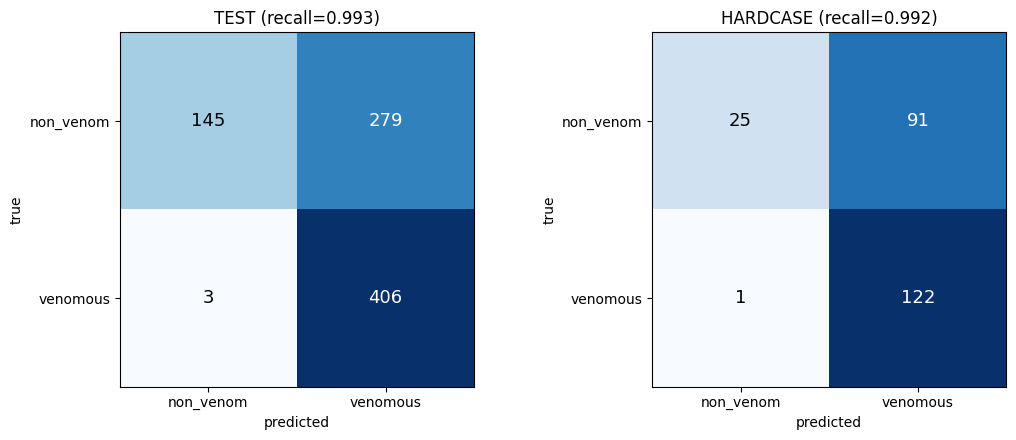

In [15]:
def plot_confusion(ax, cm: np.ndarray, title: str) -> None:
    """2x2 confusion matrix (rows=true, cols=pred; 0=non_venomous, 1=venomous)."""
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["non_venom", "venomous"]); ax.set_yticklabels(["non_venom", "venomous"])
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_confusion(axes[0], CM_TEST, f"TEST (recall={M_TEST.venomous_recall:.3f})")
plot_confusion(axes[1], CM_HARD, f"HARDCASE (recall={M_HARD.venomous_recall:.3f})")
plt.tight_layout(); plt.show()

In [16]:
def dangerous_safe_misses(frame: pd.DataFrame, X: np.ndarray, y: np.ndarray) -> pd.DataFrame:
    """Every true-venomous, predicted-non_venomous row at the threshold (the deadly errors)."""
    scores = CALIBRATED.predict_proba(X)[:, 1]
    pred = (scores >= THRESHOLD).astype(int)
    miss = (y == 1) & (pred == 0)
    out = frame.loc[miss, ["rel_path", "species", "split"]].copy()
    out["venom_prob"] = scores[miss]
    return out.sort_values("venom_prob", ascending=False)  # "almost caught" first.


MISS_TEST = dangerous_safe_misses(SPLITS["test"], X_te, y_te)
MISS_HARD = dangerous_safe_misses(SPLITS["hardcase"], X_hc, y_hc)
print(f"dangerous->safe misses  TEST={len(MISS_TEST)}  HARDCASE={len(MISS_HARD)}")
print("\n--- TEST misses (sorted by calibrated P[venom] desc) ---")
print(MISS_TEST.head(20).to_string(index=False) if len(MISS_TEST) else "  (none)")
print("\n--- HARDCASE misses ---")
print(MISS_HARD.head(20).to_string(index=False) if len(MISS_HARD) else "  (none)")

dangerous->safe misses  TEST=3  HARDCASE=1

--- TEST misses (sorted by calibrated P[venom] desc) ---
     rel_path                    species split  venom_prob
img_00788.jpg    Trimeresurus erythrurus  test    0.021277
img_01075.jpg Craspedocephalus gramineus  test    0.021277
img_01824.jpg Craspedocephalus gramineus  test    0.021277

--- HARDCASE misses ---
     rel_path            species    split  venom_prob
img_00326.jpg Bungarus caeruleus hardcase    0.021277


## 12 · Compare against the frozen baseline (0.99 / 0.935)
Small table: frozen BioCLIP (cited from `bioclip_danger_v1.meta.json`) vs this fine-tuned v2. The bar is the
hard-case recall — that is the gap fine-tuning is meant to close.

In [17]:
FROZEN_BASELINE = {"model": "BioCLIP frozen (v1)", "recall_test": 0.99, "recall_hardcase": 0.935,
                   "ece_test": np.nan, "ece_hardcase": np.nan, "gate": "MISS (hardcase)"}


def gate_str(rt: float, rh: float, g: float) -> str:
    """PASS only if BOTH splits clear the gate, else name the missing split(s)."""
    missed = [s for s, ok in (("test", rt >= g), ("hardcase", rh >= g)) if not ok]
    return "PASS" if not missed else "MISS (" + ",".join(missed) + ")"


v2_row = {"model": "BioCLIP fine-tuned (v2)",
          "recall_test": round(M_TEST.venomous_recall, 3),
          "recall_hardcase": round(M_HARD.venomous_recall, 3),
          "ece_test": round(M_TEST.ece, 3), "ece_hardcase": round(M_HARD.ece, 3),
          "gate": gate_str(M_TEST.venomous_recall, M_HARD.venomous_recall, CFG.gate)}

COMPARISON = pd.DataFrame([FROZEN_BASELINE, v2_row])[
    ["model", "recall_test", "recall_hardcase", "ece_test", "ece_hardcase", "gate"]]
print("=" * 92)
print("COMPARISON — venomous recall is the headline; gate = recall >= 0.98 on BOTH splits")
print("=" * 92)
print(COMPARISON.to_string(index=False))

COMPARISON — venomous recall is the headline; gate = recall >= 0.98 on BOTH splits
                  model  recall_test  recall_hardcase  ece_test  ece_hardcase            gate
    BioCLIP frozen (v1)        0.990            0.935       NaN           NaN MISS (hardcase)
BioCLIP fine-tuned (v2)        0.993            0.992      0.04         0.103            PASS


## 13 · Refit the Mahalanobis OOD detector on fine-tuned embeddings
Same recipe/schema as `bioclip_ood_v1.joblib`: LedoitWolf shrinkage on ALL fine-tuned embeddings; threshold =
the 99th percentile of in-distribution distances. Saved as `{mean, precision, threshold}`.

In [18]:
from sklearn.covariance import LedoitWolf


def fit_ood(X_all: np.ndarray, percentile: float) -> dict:
    """Fit Mahalanobis OOD params on in-distribution embeddings (matches MahalanobisOODDetector.fit)."""
    Xd = np.asarray(X_all, dtype=np.float64)
    lw = LedoitWolf().fit(Xd)
    mean, precision = lw.location_, lw.precision_
    delta = Xd - mean
    dists = np.sqrt(np.einsum("ij,jk,ik->i", delta, precision, delta))
    threshold = float(np.percentile(dists, percentile))
    return {"mean": mean, "precision": precision, "threshold": threshold}


X_ALL = np.concatenate([EMB[s][0] for s in ["train", "val", "test", "hardcase"]], axis=0)
OOD_PARAMS = fit_ood(X_ALL, CFG.ood_percentile)

# Sanity: fraction of test snakes (in-distribution) flagged OOD should be small.
d_te = np.sqrt(np.einsum("ij,jk,ik->i", X_te.astype(np.float64) - OOD_PARAMS["mean"],
                         OOD_PARAMS["precision"], X_te.astype(np.float64) - OOD_PARAMS["mean"]))
test_reject = float(np.mean(d_te > OOD_PARAMS["threshold"]))
print(f"OOD threshold (p{CFG.ood_percentile:.0f}) = {OOD_PARAMS['threshold']:.2f} | test snakes flagged OOD = {test_reject:.1%}")

OOD threshold (p99) = 31.27 | test snakes flagged OOD = 0.8%


## 14 · Export the 3 artifacts to `/kaggle/working/`
- `bioclip_finetuned.pt` — the fine-tuned **image-encoder** `state_dict` (load into a fresh BioCLIP, then
  re-extract embeddings to serve).
- `bioclip_danger_v2.joblib` — `{calibrated_clf, threshold, meta}` (meta incl. `recall_test`,
  `recall_hardcase`) — same schema as `bioclip_danger_v1.joblib`.
- `bioclip_ood_v2.joblib` — `{mean, precision, threshold}` — same schema as `bioclip_ood_v1.joblib`.

On Kaggle these land in `/kaggle/working/` (downloadable). In SMOKE we write to a local scratch dir instead.

In [19]:
import joblib


def output_dir() -> Path:
    """/kaggle/working when on Kaggle (downloadable); a local folder for SMOKE/dev."""
    kaggle_out = Path("/kaggle/working")
    if kaggle_out.exists():
        return kaggle_out
    out = Path.cwd() / ("smoke_outputs" if SMOKE else "outputs")
    out.mkdir(parents=True, exist_ok=True)
    return out


OUT = output_dir()
note = " [SMOKE — NOT A REAL MODEL]" if SMOKE else ""

# 1) Fine-tuned image-encoder state_dict (encoder only; head is re-derived by the serving recipe).
encoder_path = OUT / "bioclip_finetuned.pt"
torch.save(CLF.backbone.state_dict(), encoder_path)

# 2) Danger head artifact — schema identical to bioclip_danger_v1.joblib.
meta = {
    "backbone": CFG.backbone_id, "embedding_dim": int(EMB_DIM), "feature_variant": "raw",
    "positive_class": CFG.positive_class, "threshold": round(float(THRESHOLD), 4), "seed": CFG.seed,
    "recall_test": round(M_TEST.venomous_recall, 3), "recall_hardcase": round(M_HARD.venomous_recall, 3),
    "finetuned": True, "fell_back_to_clip": bool(BIOCLIP_FELL_BACK),
    "n_unfrozen_blocks": CFG.n_unfrozen_blocks, "best_epoch": TRAIN_RESULT["best_epoch"], "smoke": bool(SMOKE),
}
danger_path = OUT / "bioclip_danger_v2.joblib"
joblib.dump({"calibrated_clf": CALIBRATED, "threshold": float(THRESHOLD), "meta": meta}, danger_path)

# 3) OOD artifact — schema identical to bioclip_ood_v1.joblib.
ood_path = OUT / "bioclip_ood_v2.joblib"
joblib.dump(OOD_PARAMS, ood_path)

print(f"output dir: {OUT}{note}")
for p in (encoder_path, danger_path, ood_path):
    print(f"  saved {p.name}  ({p.stat().st_size/1e6:.2f} MB)")
print("\ndanger meta:", json.dumps(meta))

output dir: /kaggle/working
  saved bioclip_finetuned.pt  (598.60 MB)
  saved bioclip_danger_v2.joblib  (0.02 MB)
  saved bioclip_ood_v2.joblib  (2.10 MB)

danger meta: {"backbone": "hf-hub:imageomics/bioclip", "embedding_dim": 512, "feature_variant": "raw", "positive_class": "venomous", "threshold": 0.0824, "seed": 42, "recall_test": 0.993, "recall_hardcase": 0.992, "finetuned": true, "fell_back_to_clip": false, "n_unfrozen_blocks": 3, "best_epoch": 1, "smoke": false}


## 15 · Verdict
One-line gate decision based on this run.

In [20]:
both_pass = (M_TEST.venomous_recall >= CFG.gate) and (M_HARD.venomous_recall >= CFG.gate)
if SMOKE:
    print("SMOKE RUN — metrics are meaningless (tiny subset, 1 epoch). Code path validated only. "
          "Set SMOKE=False and run on Kaggle GPU for the real verdict.")
elif both_pass:
    print(f"VERDICT: GATE CLEARED. Fine-tuned BioCLIP reaches venomous recall "
          f"test={M_TEST.venomous_recall:.3f} / hardcase={M_HARD.venomous_recall:.3f} (>= {CFG.gate}) — "
          f"vs frozen 0.99 / 0.935. Ship v2.")
else:
    print(f"VERDICT: GATE NOT YET CLEARED. test={M_TEST.venomous_recall:.3f} / "
          f"hardcase={M_HARD.venomous_recall:.3f} vs gate {CFG.gate} (frozen was 0.99 / 0.935). "
          f"Next: unfreeze more blocks, raise venom class weight, add look-alike data, or longer training.")

VERDICT: GATE CLEARED. Fine-tuned BioCLIP reaches venomous recall test=0.993 / hardcase=0.992 (>= 0.98) — vs frozen 0.99 / 0.935. Ship v2.
